# Time series forecast (temperature)

In [3]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

ModuleNotFoundError: No module named 'statsmodels'

In [ ]:
DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"

MERGED_PATH = PROCESSED_DIR / "minimum_hourly_merged.csv"
STATION_ID = "72502014734"

DECOMP_PERIOD = 24
ACF_LAGS = 48
ACF_TRIM = 5000

SARIMAX_ORDER = (1, 1, 1)
SARIMAX_SEASONAL = (1, 0, 1, 24)
SARIMA_MAXITER = 100

TRAIN_END = "2025-01-01"
TEST_START = "2025-01-01"
TEST_END = "2026-01-01"

In [ ]:
# drop if empty row, average out hourly (so that it's strictly on the hour), interpolate for missing hours
def station_temp_hourly(merged_csv, station_id):
    df = pd.read_csv(merged_csv)
    df["date_local"] = pd.to_datetime(df["date_local"], utc=True, errors="coerce")
    df = df.dropna(subset=["date_local", "met_TMP"])
    sel = df[df["station_id"].astype(str) == str(station_id)].copy()
    if sel.empty:
        raise ValueError(f"no rows for station_id={station_id!r}")
    sel = sel.sort_values("date_local").set_index("date_local")
    raw = sel["met_TMP"].astype("float64")
    hourly = raw.resample("1h").mean()
    return hourly.interpolate(limit_direction="both")

In [ ]:
temp_hourly = station_temp_hourly(MERGED_PATH, STATION_ID)
temp_hourly.head()

date_local
2020-01-01 00:00:00+00:00    6.70
2020-01-01 01:00:00+00:00    6.15
2020-01-01 02:00:00+00:00    5.60
2020-01-01 03:00:00+00:00    5.60
2020-01-01 04:00:00+00:00    5.00
Freq: h, Name: met_TMP, dtype: float64

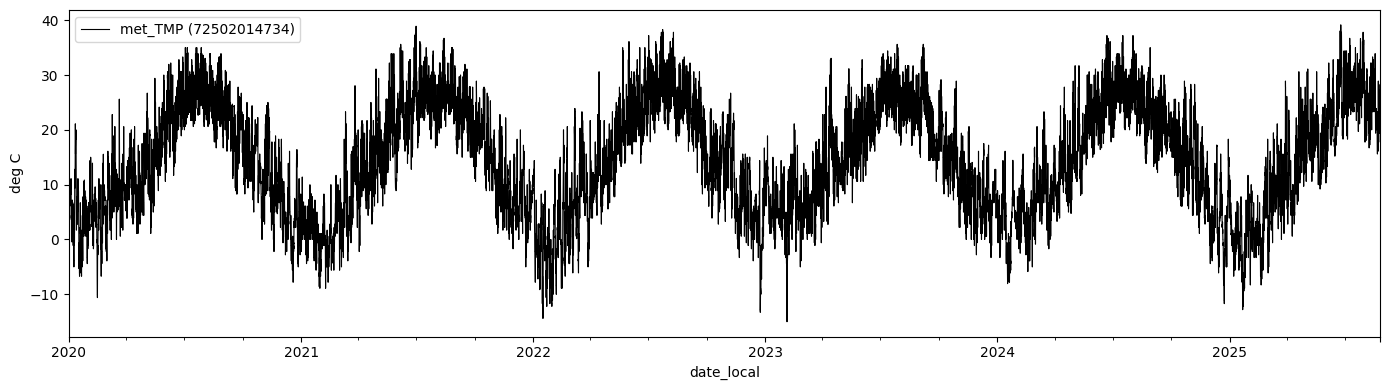

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
temp_hourly.plot(ax=ax, color="black", lw=0.8, label=f"met_TMP ({STATION_ID})")
ax.set_ylabel("deg C")
ax.legend()
plt.tight_layout()
plt.show()

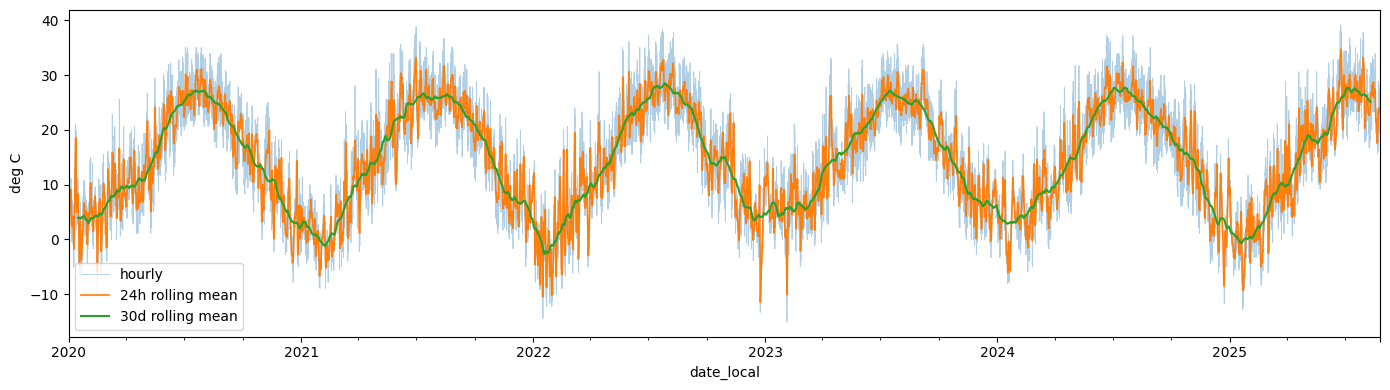

In [ ]:
# Rolling means vs hourly
roll24 = temp_hourly.rolling(24, center=True).mean()
roll_month = temp_hourly.rolling(24 * 30, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 4))
temp_hourly.plot(ax=ax, alpha=0.35, lw=0.6, label="hourly")
roll24.plot(ax=ax, lw=1.2, label="24h rolling mean")
roll_month.plot(ax=ax, lw=1.5, label="30d rolling mean")
ax.set_ylabel("deg C")
ax.legend()
plt.tight_layout()
plt.show()

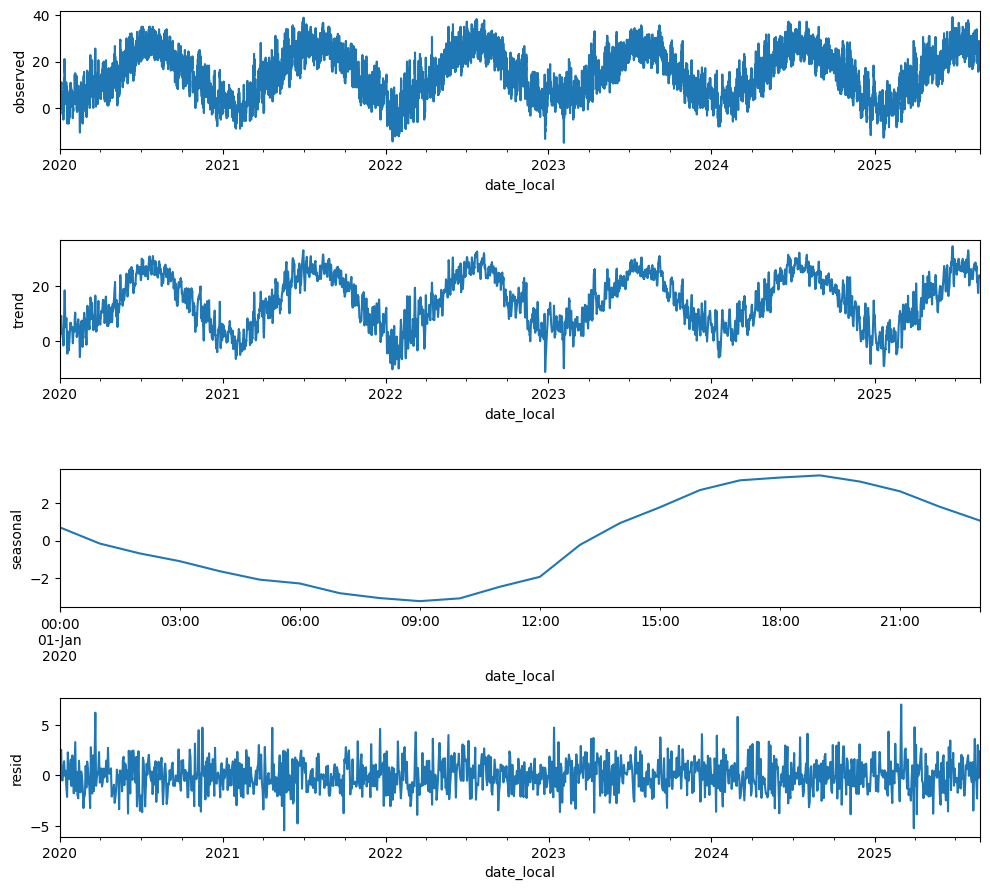

In [ ]:
# Decompose + resids
decomp = seasonal_decompose(
    temp_hourly,
    model="additive",
    period=DECOMP_PERIOD,
    extrapolate_trend="freq",
)

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=False)

temp_hourly.plot(ax=axes[0])
axes[0].set_ylabel("observed")

decomp.trend.plot(ax=axes[1])
axes[1].set_ylabel("trend")

decomp.seasonal.iloc[:24].plot(ax=axes[2]) # daily seasonal
axes[2].set_ylabel("seasonal")

decomp.resid.iloc[::40].plot(ax=axes[3]) # step size 40 just to make it readable
axes[3].set_ylabel("resid")

plt.tight_layout()
plt.show()

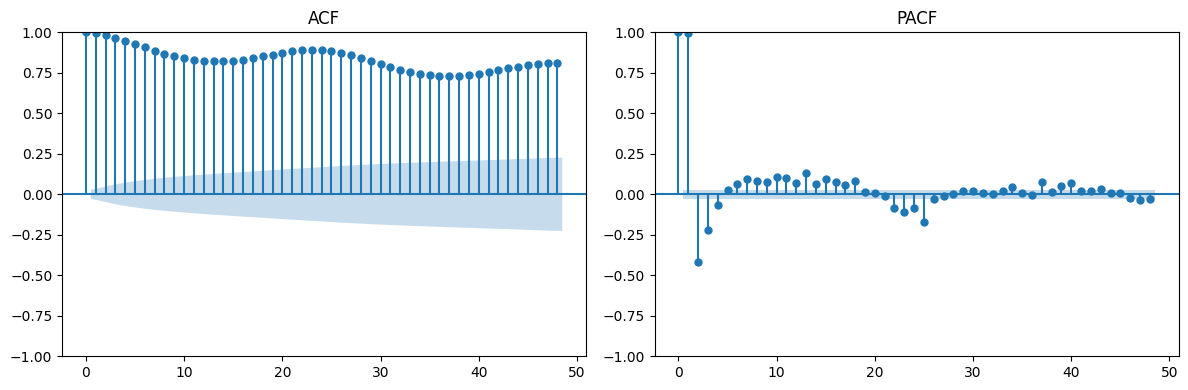

In [ ]:
n_acf = min(len(temp_hourly), ACF_TRIM)
acf_input = temp_hourly.iloc[:n_acf] - temp_hourly.iloc[:n_acf].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(acf_input, ax=axes[0], lags=ACF_LAGS, title="ACF")
plot_pacf(acf_input, ax=axes[1], lags=ACF_LAGS, method="ywm", title="PACF")
plt.tight_layout()
plt.show()

In [ ]:
# Looks extremely seasonal & daily swing, so will do a SARIMA
sarima_series = temp_hourly

train_end = pd.Timestamp(TRAIN_END, tz=sarima_series.index.tz)
test_start = pd.Timestamp(TEST_START, tz=sarima_series.index.tz)
test_end = pd.Timestamp(TEST_END, tz=sarima_series.index.tz)

y_train = sarima_series[sarima_series.index < train_end]
y_test = sarima_series[(sarima_series.index >= test_start) & (sarima_series.index < test_end)]

model = SARIMAX(
    y_train,
    order=SARIMAX_ORDER,
    seasonal_order=SARIMAX_SEASONAL,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

sarima_res = model.fit(disp=False, maxiter=SARIMA_MAXITER)

forecast = sarima_res.get_forecast(steps=len(y_test))
sarima_pred = forecast.predicted_mean

sarima_mae = np.mean(np.abs(y_test.values - sarima_pred.values))
sarima_mae

np.float64(6.882627019437405)

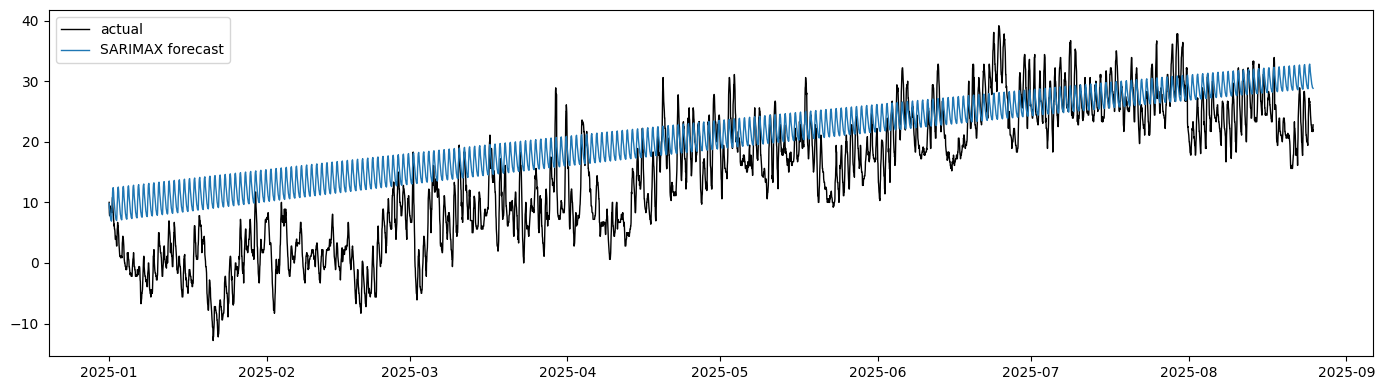

In [ ]:
# actual vs forecast 
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_test.index, y_test.values, label="actual", lw=1, color="black")
ax.plot(sarima_pred.index, sarima_pred.values, label="SARIMAX forecast", lw=1)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Monthly SARIMA
tz = sarima_series.index.tz
train_end_ts = pd.Timestamp(TRAIN_END, tz=tz)
test_start_ts = pd.Timestamp(TEST_START, tz=tz)
test_end_ts = pd.Timestamp(TEST_END, tz=tz)

MONTHLY_ORDER = (1, 0, 1)
MONTHLY_SEASONAL = (1, 1, 0, 12)
MONTHLY_MAXITER = 100

monthly_temp = sarima_series.resample("MS").mean().interpolate(limit_direction="both")
monthly_train = monthly_temp[monthly_temp.index < train_end_ts]

month_test_index = pd.date_range(test_start_ts, test_end_ts - pd.Timedelta(days=1), freq="MS", tz=tz)

monthly_seasonal_model = SARIMAX(
    monthly_train,
    order=MONTHLY_ORDER,
    seasonal_order=MONTHLY_SEASONAL,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

monthly_seasonal_res = monthly_seasonal_model.fit(disp=False, maxiter=MONTHLY_MAXITER)

monthly_forecast = monthly_seasonal_res.get_forecast(steps=len(month_test_index)).predicted_mean
monthly_forecast.index = month_test_index.to_period("M")

yearly_pred_hourly = pd.Series(
    monthly_forecast.reindex(y_test.index.to_period("M")).values,
    index=y_test.index,
)

/var/folders/kg/ts95k0w11y50gnt_r_x3y9f40000gn/T/ipykernel_44062/2487972337.py:27: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_forecast.index = month_test_index.to_period("M")
/var/folders/kg/ts95k0w11y50gnt_r_x3y9f40000gn/T/ipykernel_44062/2487972337.py:30: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_forecast.reindex(y_test.index.to_period("M")).values,


In [ ]:
# Combine
DAILY_WEIGHT = 0.1 # these are the best weights from the test below
MONTHLY_WEIGHT = 0.9

hybrid_pred = DAILY_WEIGHT * sarima_pred + MONTHLY_WEIGHT * yearly_pred_hourly

compare_mae = {
    "daily_sarima_mae": float(np.mean(np.abs(y_test.values - sarima_pred.values))),
    "monthly_sarima_mae": float(np.mean(np.abs(y_test.values - yearly_pred_hourly.values))),
    "hybrid_mae": float(np.mean(np.abs(y_test.values - hybrid_pred.values))),
}

compare_mae

{'daily_sarima_mae': 6.882627019437405,
 'monthly_sarima_mae': 4.412507184370664,
 'hybrid_mae': 4.462909967050519}

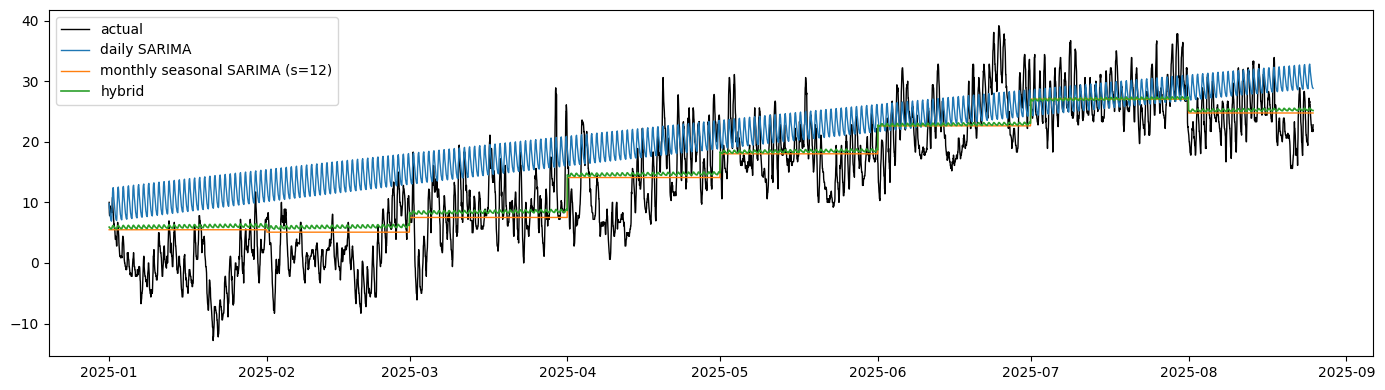

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_test.index, y_test.values, label="actual", lw=1, color="black")
ax.plot(sarima_pred.index, sarima_pred.values, label="daily SARIMA", lw=1)
ax.plot(yearly_pred_hourly.index, yearly_pred_hourly.values, label="monthly seasonal SARIMA (s=12)", lw=1)
ax.plot(hybrid_pred.index, hybrid_pred.values, label="hybrid", lw=1.2)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 0.1 to 1.0, 100 combos --> best MAE
weight_values = np.round(np.arange(0.0, 1.01, 0.1), 1)

weight_results = []
for daily_w in weight_values:
    for monthly_w in weight_values:
        blended = daily_w * sarima_pred + monthly_w * yearly_pred_hourly
        mae = float(np.mean(np.abs(y_test.values - blended.values)))
        weight_results.append({
            "daily_weight": daily_w,
            "monthly_weight": monthly_w,
            "mae": mae,
        })

weight_df = pd.DataFrame(weight_results).sort_values("mae").reset_index(drop=True)
best_weights = weight_df.iloc[0]

best_weights, weight_df.head(10)

(daily_weight      0.000000
 monthly_weight    1.000000
 mae               4.412507
 Name: 0, dtype: float64,
    daily_weight  monthly_weight       mae
 0           0.0             1.0  4.412507
 1           0.1             0.9  4.462910
 2           0.1             0.8  4.534141
 3           0.2             0.7  4.553797
 4           0.0             0.9  4.563688
 5           0.2             0.8  4.569735
 6           0.3             0.6  4.636109
 7           0.3             0.7  4.733700
 8           0.4             0.5  4.769490
 9           0.1             1.0  4.915619)

In [ ]:
# Should have done subsequent SARIMAs instead of linear combination from the start tbh

tz_h = sarima_series.index.tz
train_end_h = pd.Timestamp(TRAIN_END, tz=tz_h)
test_start_h = pd.Timestamp(TEST_START, tz=tz_h)
test_end_h = pd.Timestamp(TEST_END, tz=tz_h)

monthly_mean_hier = sarima_series.resample("MS").mean().interpolate(limit_direction="both")
monthly_train_hier = monthly_mean_hier[monthly_mean_hier.index < train_end_h]

hier_monthly_model = SARIMAX(
    monthly_train_hier,
    order=(1, 0, 1),
    seasonal_order=(1, 1, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
) # fit the monthly model

hier_monthly_res = hier_monthly_model.fit(disp=False, maxiter=SARIMA_MAXITER)
monthly_fitted = hier_monthly_res.fittedvalues
month_key = monthly_fitted.index.strftime("%Y-%m")
lvl_by_ym = pd.Series(monthly_fitted.values, index=month_key)

month_test_h = pd.date_range(test_start_h, test_end_h - pd.Timedelta(days=1), freq="MS", tz=tz_h)
monthly_fc = hier_monthly_res.get_forecast(steps=len(month_test_h)).predicted_mean
fc_by_ym = pd.Series(monthly_fc.values, index=month_test_h.strftime("%Y-%m"))

hourly_monthly_train = pd.Series(lvl_by_ym.reindex(y_train.index.strftime("%Y-%m")).values, index=y_train.index)
resid_train = y_train - hourly_monthly_train 
# train the subsequent hourly model on the residuals from the monthly model
# hence why hierarchical 

hourly_monthly_test = pd.Series(fc_by_ym.reindex(y_test.index.strftime("%Y-%m")).values, index=y_test.index)

# Residual stage: d=0 instead of SARIMAX_ORDER's d=1—reduces long-horizon level drift on residuals.
HIER_RESIDUAL_ORDER = (1, 0, 1)

hier_hourly_model = SARIMAX(
    resid_train,
    order=HIER_RESIDUAL_ORDER,
    seasonal_order=SARIMAX_SEASONAL,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

hier_hourly_res = hier_hourly_model.fit(disp=False, maxiter=SARIMA_MAXITER)
resid_fcst = hier_hourly_res.get_forecast(steps=len(y_test)).predicted_mean
hierarchical_pred = hourly_monthly_test + resid_fcst 
# combine the two

hierarchical_mae = float(np.mean(np.abs(y_test.values - hierarchical_pred.values)))
hierarchical_mae

4.056834689653834

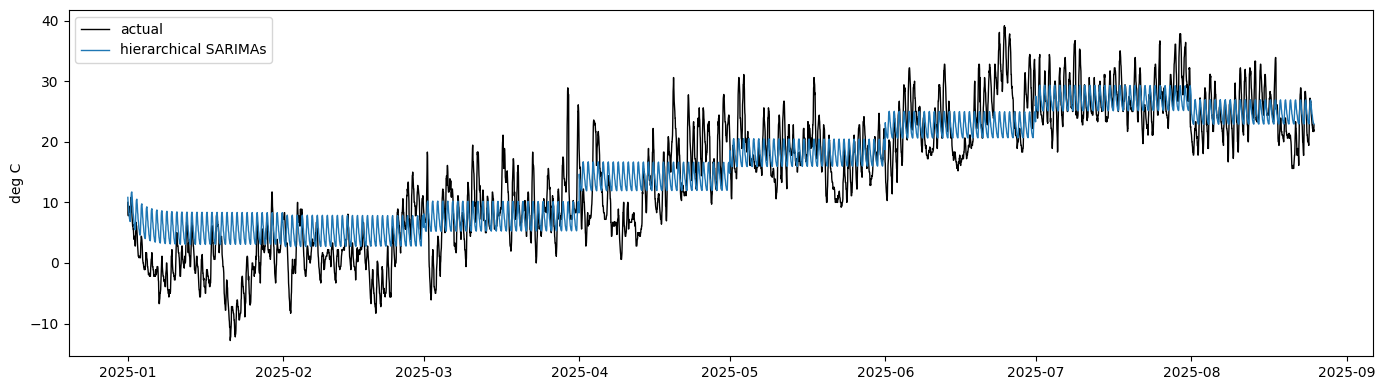

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_test.index, y_test.values, label="actual", lw=1, color="black")
ax.plot(
    hierarchical_pred.index,
    hierarchical_pred.values,
    label="hierarchical SARIMAs",
    lw=1,
)
ax.set_ylabel("deg C")
ax.legend()
plt.tight_layout()
plt.show()